## Project Overview

As loan default rates rise in 2025, banks and financial institutions face increasing pressure to identify high-risk borrowers before approving loans. This project builds a classification model to predict whether a borrower will default.

**Dataset:** 255,347 loan records with 17 borrower and loan features  
**Target:** Default (1 = defaulted, 0 = did not default)  
**Focus Metric:** Recall — catching actual defaulters is more critical than overall accuracy

## Step 1 - Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score, recall_score

from xgboost import XGBClassifier

print('All libraries are successfully loaded')

All libraries are successfully loaded


## Step 2 - Load & Inspect Data

In [2]:
# Load csv data into a dataframe using pandas
df = pd.read_csv("C:/Users/sreej/Downloads/archive (1)/Loan_default.csv")

# Display first 5 rows
df.head()
np.sort(df['EmploymentType'].unique())

array(['Full-time', 'Part-time', 'Self-employed', 'Unemployed'],
      dtype=object)

In [3]:
# How many rows and columns are in our data?
print(f'Shape of the data: {df.shape}')

Shape of the data: (255347, 18)


In [4]:
# Check data type of every column
# Helps identify which columns need encoding
print('Column Data Types:')
print(df.dtypes)

Column Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object


In [5]:
# Check for missing values

missing = df.isnull().sum().sum()
print('Total missing values:', missing)

if missing == 0:
    print('Dataset is clean — no missing values found')

Total missing values: 0
Dataset is clean — no missing values found


In [6]:
# Check target column distribution
# Important to understand class balance before modelling

print('Default Distribution:')
print(df['Default'].value_counts())
print()
print('Default Rate:')
print(df['Default'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
# Note: Dataset is imbalanced — 88.3% no default vs 11.6% default

Default Distribution:
0    225694
1     29653
Name: Default, dtype: int64

Default Rate:
0    88.39%
1    11.61%
Name: Default, dtype: object


## Step 3 - Exploratory Data Analysis (EDA)

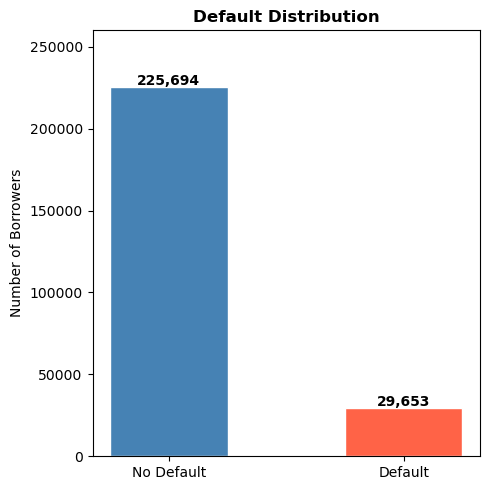

Default rate: 11.61%


In [7]:
# Visual 1 - Overall Default Distribution

count = df['Default'].value_counts()

plt.figure(figsize = (5, 5))
bars = plt.bar(['No Default', 'Default'], count.values, color=['steelblue', 'tomato'], width = 0.5, edgecolor = 'white')

# Add count labels on top of each bar
for bar, val in zip(bars, count.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             '{:,}'.format(val), ha='center', fontweight='bold', fontsize=10)

plt.title('Default Distribution', fontweight='bold')
plt.ylabel('Number of Borrowers')
plt.ylim(0, 260000)
plt.tight_layout()
plt.show()

print('Default rate: {:.2f}%'.format(df['Default'].mean() * 100))

# We handle this using class_weight='balanced' in our models

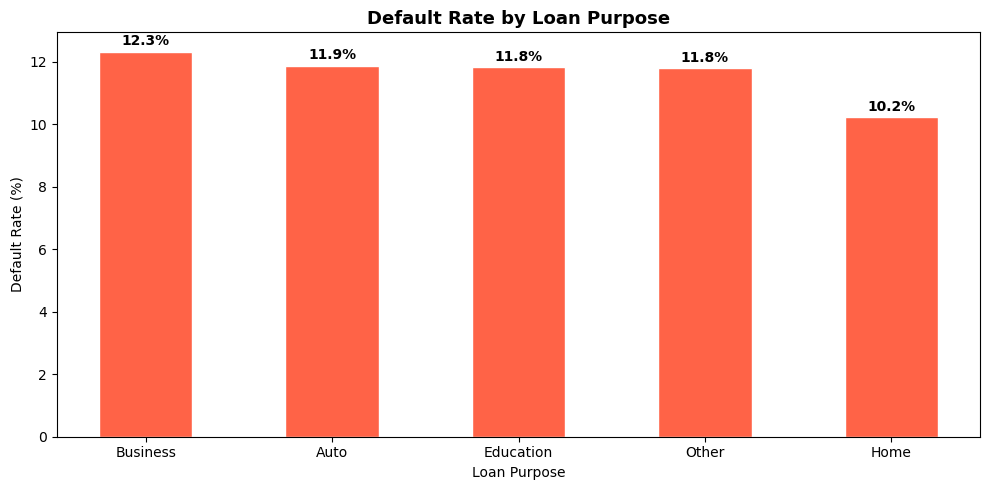

Highest default rate: Business - 12.33 %
Lowest default rate : Home - 10.23 %


In [8]:
# Visual 2 - Default Rate by Loan Purpose
# Identifies which loan purposes carry the highest default risk

purpose_default = df.groupby('LoanPurpose')['Default'].mean().mul(100).round(2)
purpose_default = purpose_default.sort_values(ascending = False)

plt.figure(figsize=(10, 5))
bars = plt.bar(purpose_default.index, purpose_default.values, color = 'tomato', edgecolor = 'white', width = 0.5)

for bar, val in zip(bars, purpose_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             '{:.1f}%'.format(val), ha = 'center', fontweight = 'bold', fontsize = 10)

plt.title('Default Rate by Loan Purpose', fontweight='bold', fontsize=13)
plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Purpose')
plt.tight_layout()
plt.show()

print('Highest default rate:', purpose_default.index[0], '-', purpose_default.values[0], '%')
print('Lowest default rate :', purpose_default.index[-1], '-', purpose_default.values[-1], '%')

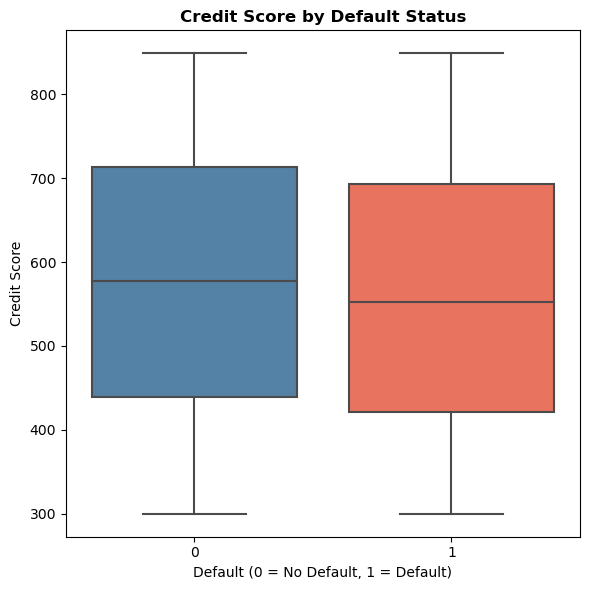

Avg credit score — No Default: 576
Avg credit score — Default   : 559


In [9]:
# Visual 3 — Credit Score: Defaulters vs Non-Defaulters
# Box plot shows distribution of credit scores for each class

plt.figure(figsize = (6, 6))
sns.boxplot(data = df, x = 'Default', y = 'CreditScore', palette = ['steelblue', 'tomato'])

plt.title('Credit Score by Default Status', fontweight='bold')
plt.xlabel('Default (0 = No Default, 1 = Default)')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

print('Avg credit score — No Default: {:.0f}'.format( df[df['Default']==0]['CreditScore'].mean()))
print('Avg credit score — Default   : {:.0f}'.format( df[df['Default']==1]['CreditScore'].mean()))

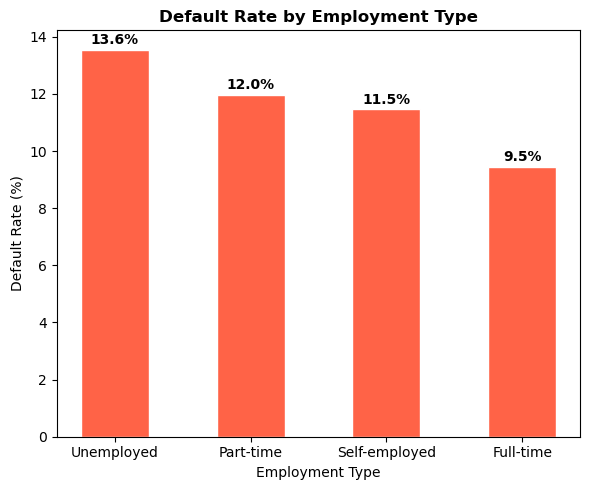

In [10]:
# Visual 4 — Default Rate by Employment Type
# Shows which employment types are associated with higher default risk

etype = df.groupby('EmploymentType')['Default'].mean().mul(100).round(2)
etype = etype.sort_values(ascending = False)

plt.figure(figsize = (6, 5))
bars = plt.bar(etype.index, etype.values, color = 'tomato', width = 0.5, edgecolor = 'white')

for bar, val in zip(bars, etype.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             '{:.1f}%'.format(val), ha = 'center', fontweight = 'bold', fontsize = 10)

plt.title('Default Rate by Employment Type', fontweight = 'bold')
plt.ylabel('Default Rate (%)')
plt.xlabel('Employment Type')
plt.tight_layout()
plt.show()

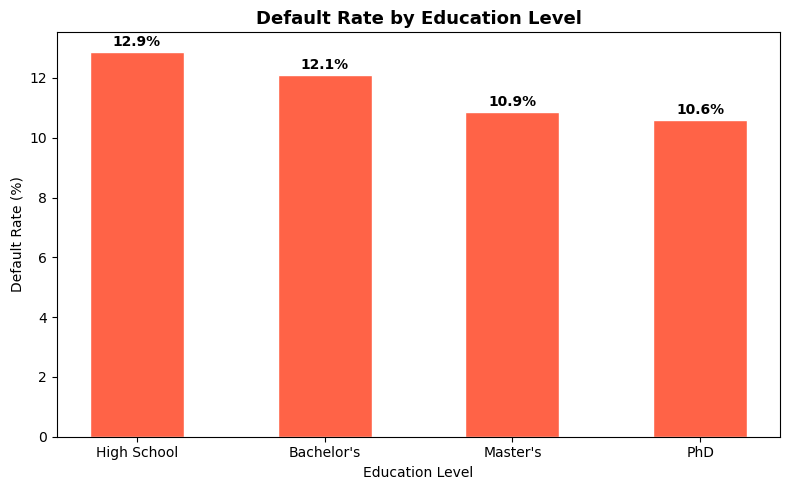

Highest default rate: High School - 12.88 %
Lowest default rate : PhD - 10.59 %


In [11]:
# Visual 5 - Default Rate by Education Level
# Higher education may correlate with better financial management

edtype = df.groupby('Education')['Default'].mean().mul(100).round(2)
edtype = edtype.sort_values(ascending = False)

plt.figure(figsize=(8, 5))
bars = plt.bar(edtype.index, edtype.values, color = 'tomato', edgecolor = 'white', width = 0.5)

for bar, val in zip(bars, edtype.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             '{:.1f}%'.format(val), ha = 'center', fontweight = 'bold', fontsize = 10)

plt.title('Default Rate by Education Level', fontweight='bold', fontsize=13)
plt.ylabel('Default Rate (%)')
plt.xlabel('Education Level')
plt.tight_layout()
plt.show()

print('Highest default rate:', edtype.index[0], '-', edtype.values[0], '%')
print('Lowest default rate :', edtype.index[-1], '-', edtype.values[-1], '%')

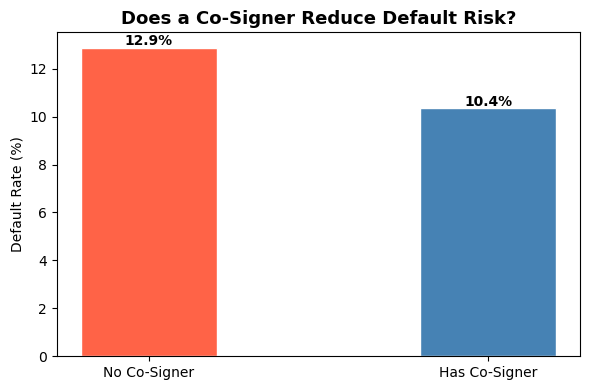

Default rate with co-signer   : 10.36 %
Default rate without co-signer: 12.87 %


In [12]:
# Visual 6 - Does Having a Co-Signer Reduce Default Risk?
# A co-signer shares liability — does it actually reduce defaults?

signer = df.groupby('HasCoSigner')['Default'].mean().mul(100).round(2)

plt.figure(figsize = (6, 4))
bars = plt.bar(['No Co-Signer', 'Has Co-Signer'], signer.values, color = ['tomato', 'steelblue'], edgecolor = 'white', width = 0.4)

for bar, val in zip(bars, signer.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             '{:.1f}%'.format(val), ha = 'center', fontweight = 'bold')

plt.title('Does a Co-Signer Reduce Default Risk?', fontweight = 'bold', fontsize = 13)
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

print('Default rate with co-signer   :', signer['Yes'], '%')
print('Default rate without co-signer:', signer['No'],  '%')

## Step 4 - Data Cleaning & Preprocessing

In [13]:
# Drop LoanID as it carries no information useful for prediction

df = df.drop(columns=['LoanID'])
print('LoanID dropped')
print('New shape:', df.shape)

LoanID dropped
New shape: (255347, 17)


In [14]:
# Encoding binary columns to Yes - 1, No - 0

yes_no_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print('Yes/No columns encoded:')
print(df[yes_no_cols].head())

Yes/No columns encoded:
   HasMortgage  HasDependents  HasCoSigner
0            1              1            1
1            0              0            1
2            1              1            0
3            0              0            0
4            0              1            0


In [15]:
# Encode remaining categorical columns
# LabelEncoder converts text categories to integers
# e.g. Education: 'Bachelor' → 0, 'High School' → 1, 'Master' → 2, 'PhD' → 3

labelenc = LabelEncoder()
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']

for col in categorical_cols:
    df[col] = labelenc.fit_transform(df[col])
    print('{} encoded'.format(col))

print('\nAll columns after encoding:')
print(df.dtypes)

Education encoded
EmploymentType encoded
MaritalStatus encoded
LoanPurpose encoded

All columns after encoding:
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education           int32
EmploymentType      int32
MaritalStatus       int32
HasMortgage         int64
HasDependents       int64
LoanPurpose         int32
HasCoSigner         int64
Default             int64
dtype: object


In [16]:
# Confirm first 5 rows after all cleaning steps
print('First 5 rows after cleaning:')
df.head()

First 5 rows after cleaning:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


## Step 5 - Prepare Data for ML

In [17]:
# Separate features and target 

X = df.drop(columns=['Default'])
Y = df['Default']

print('X shape:', X.shape)
print('Y shape:', Y.shape)
print('Features:', X.columns.tolist())

X shape: (255347, 16)
Y shape: (255347,)
Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [18]:
# Train Test Split 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 42)

print('Training samples :', X_train.shape[0])
print('Testing samples  :', X_test.shape[0])
print()

Training samples : 204277
Testing samples  : 51070



In [19]:
# Feature Scaling 
# StandardScaler rescales every feature to mean=0 and std=1
# Required for Logistic Regression which is sensitive to feature scale

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling done!')

Scaling done!


## Step 6 - Build & Compare Models

In [20]:
# Cross validation on 3 models

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

model1 = LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42)
model2 = RandomForestClassifier(n_estimators = 50, class_weight = 'balanced', random_state = 42)
model3 = XGBClassifier(n_estimators = 100, scale_pos_weight = 8, random_state = 42, eval_metric = 'logloss')

score1 = cross_val_score(model1, X_train_sc, Y_train, cv = cv, scoring = 'recall')
score2 = cross_val_score(model2, X_train_sc, Y_train, cv = cv, scoring = 'recall')
score3 = cross_val_score(model3, X_train_sc, Y_train, cv = cv, scoring = 'recall')

print('Logistic Regression      - recall      {:.2f}%'.format(score1.mean()*100))
print('Random Forest Classifier - recall {:.2f}%'.format(score2.mean()*100))
print('XGBoost                  - recall {:.2f}%'.format(score3.mean()*100))

Logistic Regression      - recall      68.62%
Random Forest Classifier - recall 2.72%
XGBoost                  - recall 60.49%


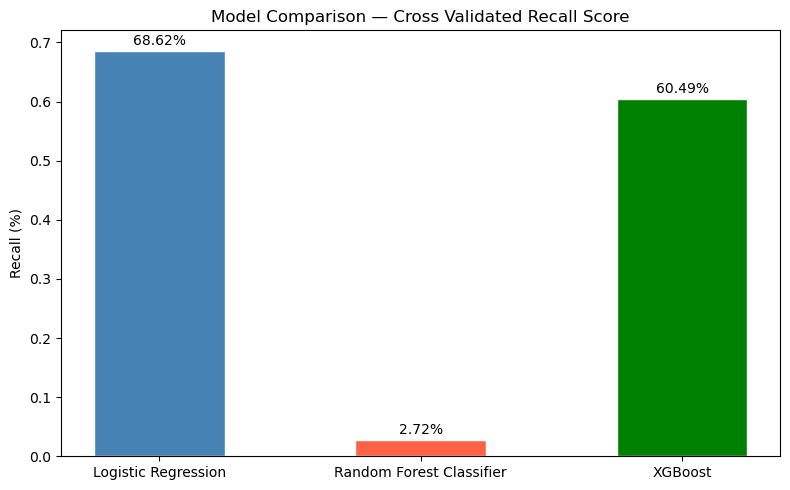

In [21]:
# Bar chart comparing model recall scores

model_names = ['Logistic Regression', 'Random Forest Classifier', 'XGBoost']
model_recall = [score1.mean(), score2.mean(), score3.mean()]

fig = plt.figure(figsize = (8,5))
bars = plt.bar(model_names, model_recall, color = ['steelblue', 'tomato', 'green'], edgecolor = 'white', width = 0.5)

for bar,score in zip(bars,model_recall):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, '{:.2f}%'.format(score*100), ha = 'center')

plt.title('Model Comparison — Cross Validated Recall Score')
plt.ylabel('Recall (%)')
plt.tight_layout()
plt.show()

## Step 7 - Hyperparameter Tuning

In [22]:
#  Hyperparameter tuning = trying different settings to find the best combination.

# This is called a 'parameter grid'
# It is just a dictionary listing all the values we want to test

param_grid = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr_model = LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42)

cv_tune = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

# Set up GridSearchCV
# estimator  = which model to tune
# param_grid = which settings to try
# cv = cv_tune = use same 3-fold stratified CV as Step 5
# scoring    = measure performance by recall
# verbose = 1  = print progress while it runs

grid_search = GridSearchCV(estimator = lr_model, param_grid = param_grid, cv = cv_tune, scoring = 'recall', verbose = 1)

# We use X_train_standard and Y_train
grid_search.fit(X_train_sc, Y_train)

print('Best settings found after HyperTuning:')
print('C value:', grid_search.best_params_['C'])
print('Solver value:', grid_search.best_params_['solver'])

print('\nHyperTuned Recall Score: {:.2f}%'.format(grid_search.best_score_ * 100))
print('Original Model Recall Score: {:.2f}%'.format(score1.mean()* 100))

print('\nImprovement after tuning: +{:.2f}%'.format((grid_search.best_score_ - score1.mean()) * 100))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best settings found after HyperTuning:
C value: 0.01
Solver value: liblinear

HyperTuned Recall Score: 68.70%
Original Model Recall Score: 68.62%

Improvement after tuning: +0.08%


In [23]:
# Final model from the best estimator

best_model = grid_search.best_estimator_

print('Best model is ready')
print('Settings:', best_model)

Best model is ready
Settings: LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


## Step 8 - Evaluate Tuned Model on Test Set

In [24]:
# Make predictions on test set

Y_pred = best_model.predict(X_test_sc)
Y_pred_prob = best_model.predict_proba(X_test_sc)[:, 1]  # default probability


accuracy = accuracy_score(Y_test, Y_pred) * 100
recall   = recall_score(Y_test, Y_pred)   * 100
auc      = roc_auc_score(Y_test, Y_pred_prob)

print('=== Final Model Performance on Test Set ===')
print()
print('Accuracy      : {:.2f}%'.format(accuracy))
print('Recall        : {:.2f}%'.format(recall))
print('ROC AUC Score : {:.4f}'.format(auc))
print()

=== Final Model Performance on Test Set ===

Accuracy      : 67.37%
Recall        : 70.39%
ROC AUC Score : 0.7498



In [25]:
# ── Full classification report ────────────────────────────────────────────────
# Precision: of predicted defaults, how many were actually defaults?
# Recall:    of actual defaults, how many did we correctly catch?
# F1-score:  balance between precision and recall

print('Detailed Classification Report:')
print(classification_report(Y_test, Y_pred, target_names = ['No Default', 'Default']))

Detailed Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.67      0.78     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.67      0.73     51070



<Figure size 500x400 with 0 Axes>

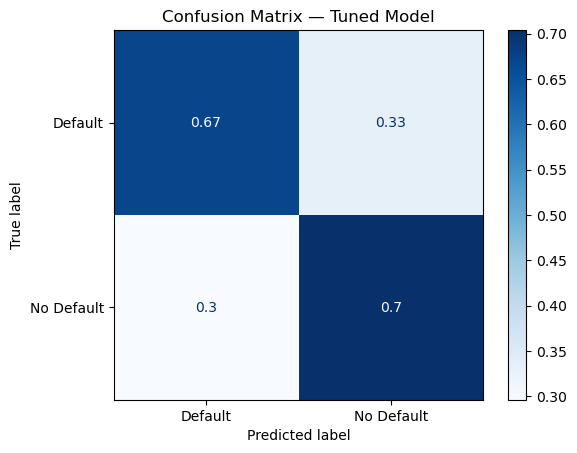

In [26]:
# Confusion Matrix 

plt.figure(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, normalize = 'true', display_labels = ['Default', 'No Default'], cmap = 'Blues')
plt.title('Confusion Matrix — Tuned Model')
plt.show()

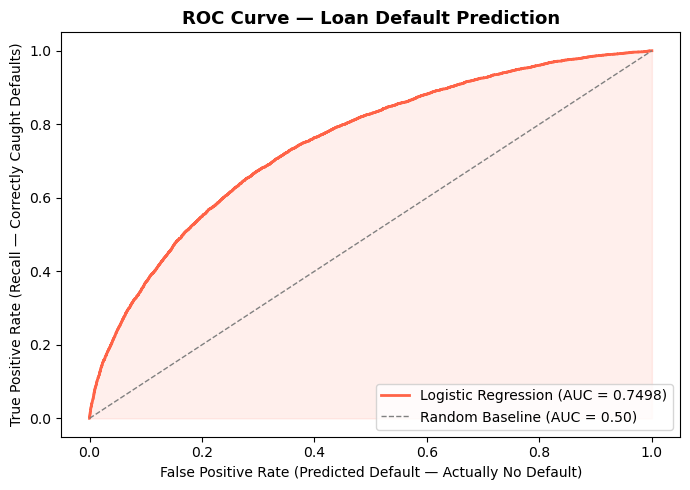

AUC Score: 0.7498
Our model significantly outperforms random guessing


In [27]:
# ROC Curve visualises model's ability to separate defaulters from non-defaulters
# AUC = Area Under Curve: 1.0 = perfect, 0.5 = random guess

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', linewidth=2, label='Logistic Regression (AUC = {:.4f})'.format(auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Baseline (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='tomato')
plt.title('ROC Curve — Loan Default Prediction', fontweight='bold', fontsize=13)
plt.xlabel('False Positive Rate (Predicted Default — Actually No Default)')
plt.ylabel('True Positive Rate (Recall — Correctly Caught Defaults)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('AUC Score: {:.4f}'.format(auc))
print('Our model significantly outperforms random guessing')

## Step 9 - Feature Importance (Logistic Regression Coefficients)

In [28]:
# Extract feature coefficients

feature_names = X.columns.tolist()
coefficients = best_model.coef_[0]

# Create a dataframe for easy plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
importance_df = importance_df.reindex(importance_df['Coefficient'].abs().sort_values(ascending=False).index)

print('Top 10 Features by Coefficient Magnitude:')
print(importance_df.head(10).to_string(index=False))

Top 10 Features by Coefficient Magnitude:
       Feature  Coefficient
           Age    -0.580899
  InterestRate     0.456422
MonthsEmployed    -0.335342
        Income    -0.312203
    LoanAmount     0.285555
EmploymentType     0.142905
   HasCoSigner    -0.128722
 HasDependents    -0.125978
   CreditScore    -0.124124
NumCreditLines     0.101574


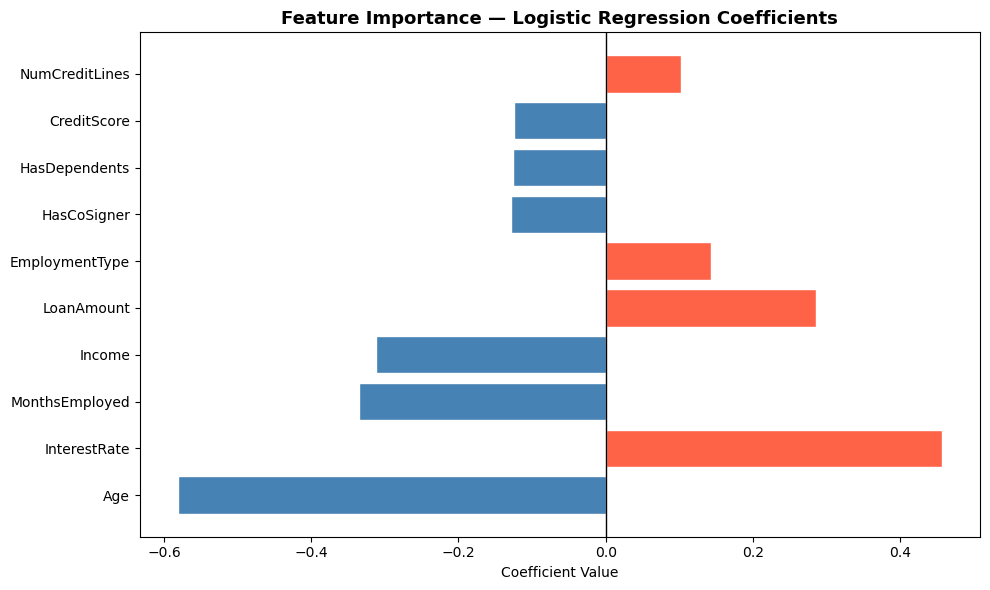


Red  → increases default risk
Blue → decreases default risk


In [29]:
# Bar chart - Feature Importance
top10 = importance_df.head(10)

colors = ['tomato' if c > 0 else 'steelblue' for c in top10['Coefficient']]

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Feature'], top10['Coefficient'], color=colors, edgecolor='white')

plt.axvline(0, color='black', linewidth=1)
plt.title('Feature Importance — Logistic Regression Coefficients', fontweight='bold', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print()
print('Red  → increases default risk')
print('Blue → decreases default risk')

## Step 10 - Export Results for Power BI

In [30]:
# File 1 - Loan predictions with risk scores
# Copy test features and add prediction columns
X_test_original = X_test.copy()
X_test_original['Actual_Default']   = Y_test.values
X_test_original['Predicted_Default'] = Y_pred
X_test_original['Default_Probability'] = (best_model.predict_proba(X_test_sc)[:, 1] * 100).round(2)

X_test_original.to_csv('loan_predictions.csv', index=False)
print('loan_predictions.csv saved')

# File 2 - Feature importance
importance_df[['Feature', 'Coefficient']].to_csv('feature_importance.csv', index=False)
print('feature_importance.csv saved')

print()
print('All files exported successfully!')
print('Files are saved in the same folder as your notebook')

loan_predictions.csv saved
feature_importance.csv saved

All files exported successfully!
Files are saved in the same folder as your notebook


## Step 11 - Save Model & Scaler

In [31]:
import pickle

with open('loan_default_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('loan_default_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model saved  → loan_default_model.pkl')
print('Scaler saved → loan_default_scaler.pkl')

Model saved  → loan_default_model.pkl
Scaler saved → loan_default_scaler.pkl


##  Summary

| Step | What We Did |
|------|-------------|
| 1 | Imported and configured all required libraries |
| 2 | Loaded 255,347 loan records and performed data quality checks |
| 3 | Conducted exploratory data analysis — 6 business questions answered visually |
| 4 | Removed identifier column and encoded all categorical and binary features |
| 5 | Applied stratified train/test split and StandardScaler feature normalisation |
| 6 | Benchmarked Logistic Regression, Random Forest and XGBoost on Recall score |
| 7 | Optimised Logistic Regression using GridSearchCV across 10 hyperparameter combinations |
| 8 | Evaluated final model on a fully held-out test set |
| 9 | Extracted and visualised feature importances from model coefficients |
| 10 | Exported predictions and feature importance files for Power BI dashboard |
| 11 | Persisted final model and scaler to disk for future deployment |

**Best Model:** Logistic Regression with `class_weight='balanced'`  
**Optimal Parameters:** C = 0.01, Solver = liblinear  
**Recall Score:** 68.70%  
**ROC AUC Score:** 0.75  

**Key Finding:** Interest Rate is the strongest predictor of loan default, borrowers with high interest rates are significantly more likely to default, likely because high rates are assigned to borrowers already flagged as risky by lenders.
